In [1]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix,make_scorer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from joblib import load,dump

In [2]:
testsize=0.4
plt.rc('font',size=8,family='serif')

# file = r"/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/new random comp generator/GEOROC data/processed minerals/molar tables/new data/compiled9.xlsx"
path='D:/Research/'
file = path+r"Mineral identifier ann IISER Mohali/new random comp generator/GEOROC data/processed minerals/molar tables/new data/compiled9_2.xlsx"
# f1 = make_scorer(f1_score, average=over_metrics)
# parameters = {'n_estimators' : [i for i in range(50,1000,50)], 'max_depth': [i for i in range(0,100,10)]}
# model_test = RandomForestClassifier()
# model = GridSearchCV(model_test, param_grid=parameters,verbose=3,scoring=f1,cv=5,n_jobs=6)
# model = RandomForestClassifier(max_depth=None,n_estimators=10,max_features='log2')

# model = RandomForestClassifier(min_samples_split=5,n_estimators=6,max_features='sqrt')

plt.rc('font',size=10,family='serif')
figsize=(10,10)
lw = 1

over_metrics="weighted"
sample_metrics="weighted"

data = pd.read_excel(file,header=0,index_col=0)
data.pop('Source')
data1 = data.copy()
data1

,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,P2O5,CO2,Mineral
S No.,,,,,,,,,,,,
0,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
658,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
659,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
660,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
661,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Als
...,...,...,...,...,...,...,...,...,...,...,...,...
41956,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cor
41957,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cor
41958,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cor


In [3]:
model = RandomForestClassifier(n_estimators=50,max_features='sqrt',bootstrap=True,class_weight='balanced',oob_score=True,n_jobs=8)



Testing for raw input data

99.95
Als: accuracy: 100.0
Amp: accuracy: 99.98
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 99.85000000000001
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C1.lbl']

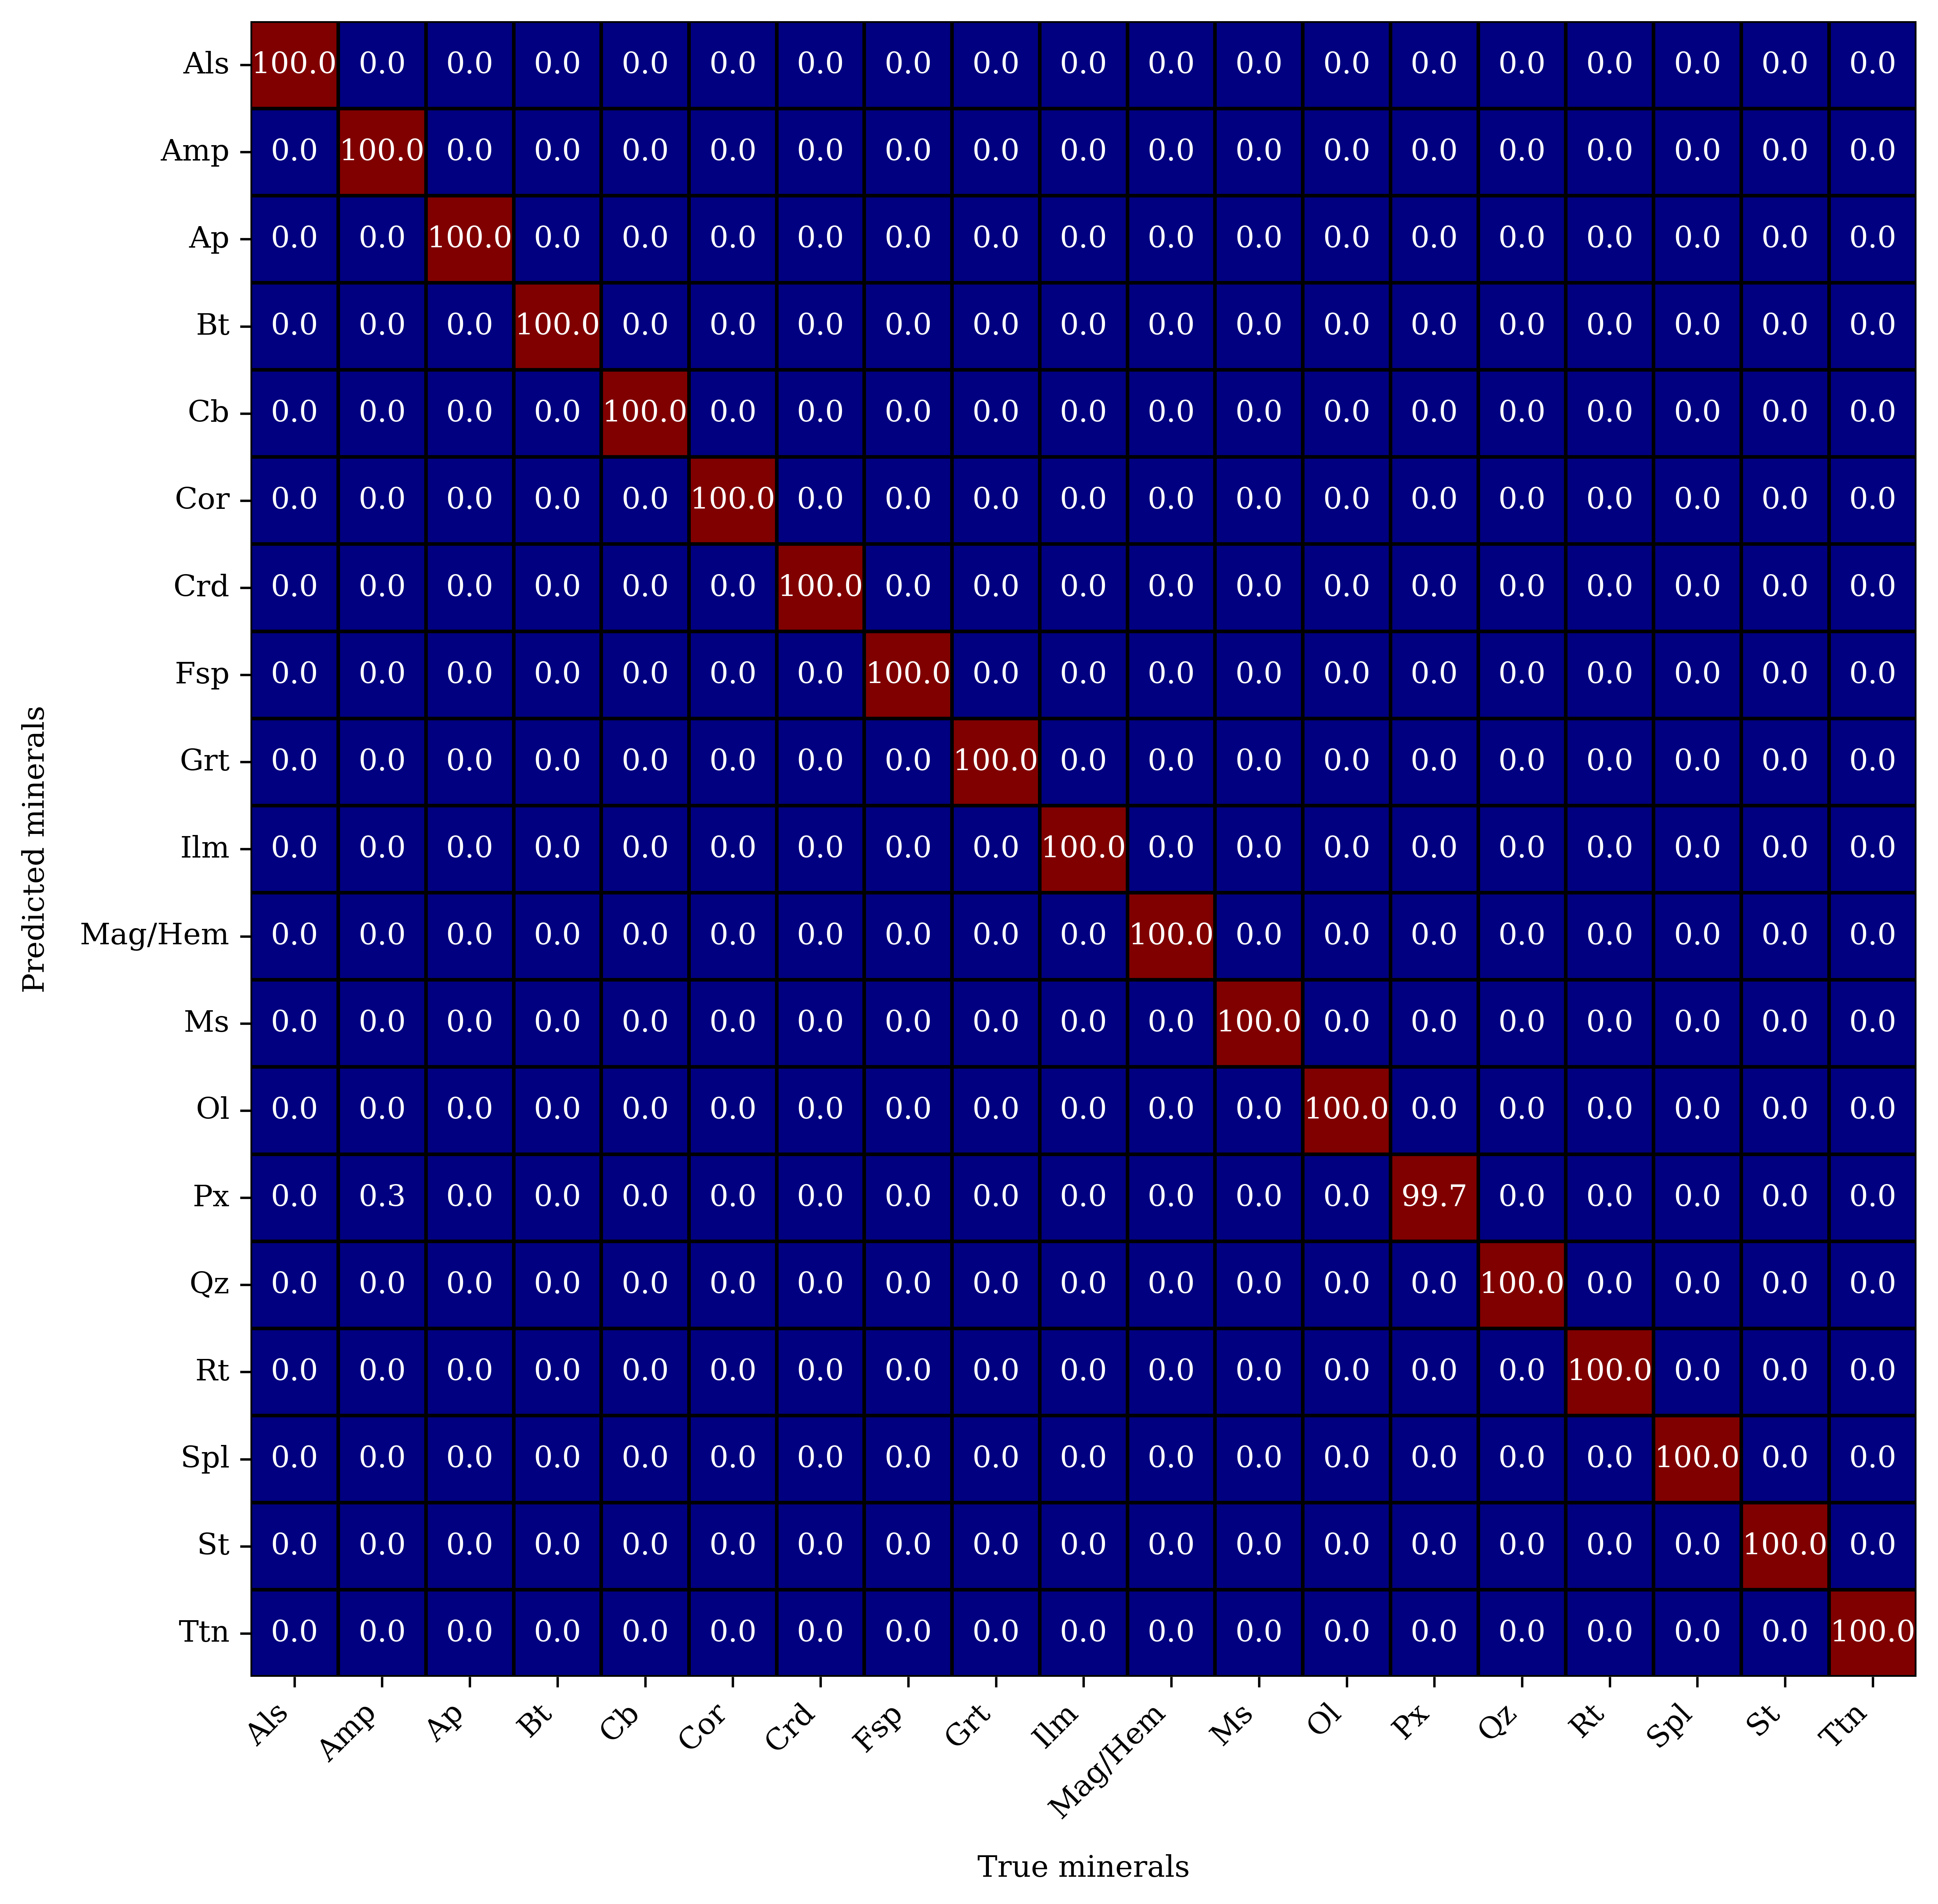

In [4]:
data = data1.copy()
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

# scaler = MinMaxScaler(feature_range=(-1,1))
# scaler = MinMaxScaler()
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(data.iloc[:,:-2])

data_scaled = data.iloc[:,:-1].to_numpy()

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

minerals = len(labeler.classes_)+1
acc_table = np.zeros((minerals,14))
recall_table = np.zeros((minerals,14))
precision_table = np.zeros((minerals,14))

#%%
splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for raw input data\n")

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,0] = a
precision_table[0,0] = p
recall_table[0,0] = r
print(round(a,2))
cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("RF_C1.pdf",bbox_inches='tight')
# plt.axes(

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,0] = a
    precision_table[i+1,0] = p
    recall_table[i+1,0] = r
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

# for i in range(0,m):
#     test_data1 = data_scaled[target==i]
#     test_label1 = target[target==i]
#     pred_label1 = model.predict(test_data1)
#     a = round(f1_score(test_label1, pred_label1, average=sample_metrics),4)*100
#     acc_table[i+1,0] = a
#     name = labeler.inverse_transform([i])[0]
#     print(f"{name}: accuracy: {a}")

pred_label = model.predict(data_scaled)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]
test_data_df_mismatch

dump(model,"RF_C1.mdl")
# dump(scaler,"Scaler_C1.scl")
dump(labeler,"Labeler_C1.lbl")

In [5]:
data_scaled.shape

(47031, 11)


Testing for FeO+MnO+MgO input data

99.97
Als: accuracy: 100.0
Amp: accuracy: 99.98
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 99.92999999999999
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C2.lbl']

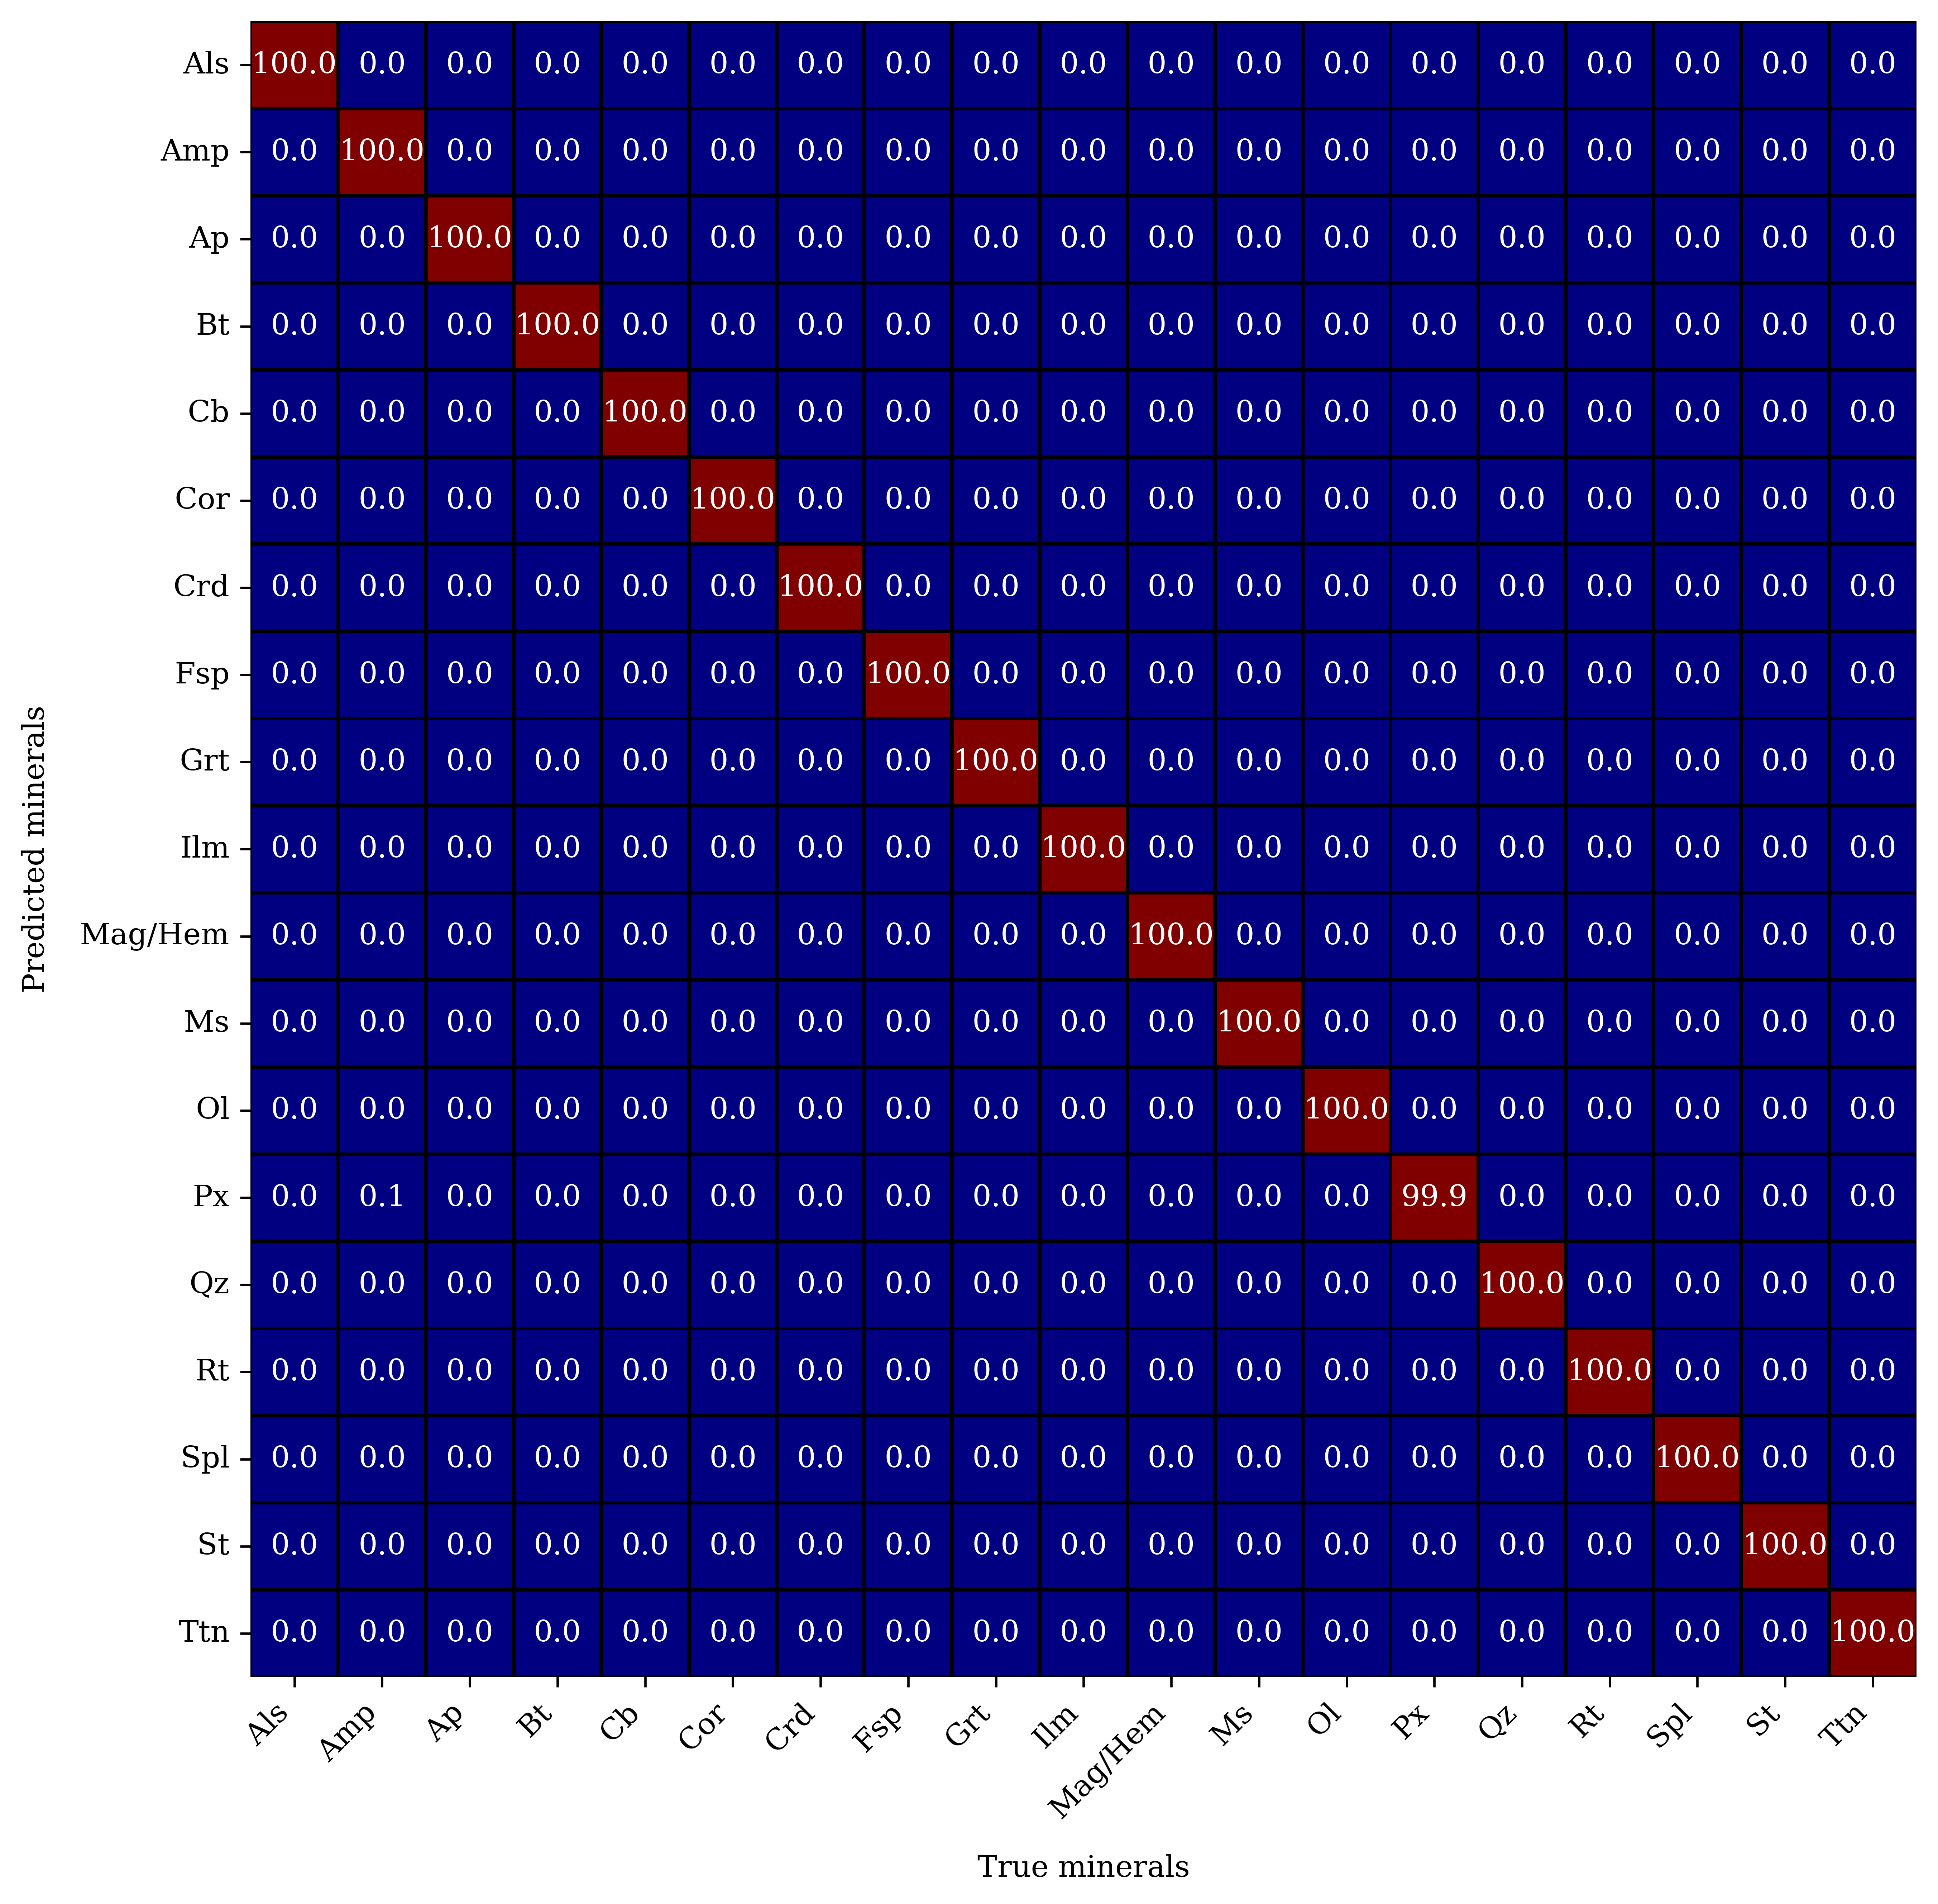

In [6]:
data = data1.copy()
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data['M'] = data['FeO']+data['MgO']+data['MnO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")


data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'Na2O', 'K2O', 'P2O5','CO2','Mineral']]

# data['Al/Si'] = (data["Al2O3"]-data['SiO2'])/(data['SiO2']+data['Al2O3'])

# data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A', 'Al/Si',
#        'Mineral', 'Source']]
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(data.iloc[:,:-2])

data_scaled = data.iloc[:,:-1].to_numpy()

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for FeO+MnO+MgO input data\n")

# model = RandomForestClassifier(max_depth=7,n_estimators=5,max_features=0.4)

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,1] = a
precision_table[0,1] = p
recall_table[0,1] = r
print(round(a,2))
cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("RF_C2.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,1] = a
    precision_table[i+1,1] = p
    recall_table[i+1,1] = r
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

# for i in range(0,16):
#     test_data1 = data_scaled[target==i]
#     test_label1 = target[target==i]
#     pred_label1 = model.predict(test_data1)
#     a = round(f1_score(test_label1, pred_label1, average=sample_metrics),4)*100
#     acc_table[i+1,0] = a
#     name = labeler.inverse_transform([i])[0]
#     print(f"{name}: accuracy: {a}")

pred_label = model.predict(data_scaled)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]

dump(model,"RF_C2.mdl")
# dump(scaler,"Scaler_C2.scl")
dump(labeler,"Labeler_C2.lbl")


Testing for FeO+MnO+MgO and Na2O+K2O input data

99.96
Als: accuracy: 100.0
Amp: accuracy: 99.96000000000001
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 99.88
Ol: accuracy: 100.0
Px: accuracy: 99.92999999999999
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C3.lbl']

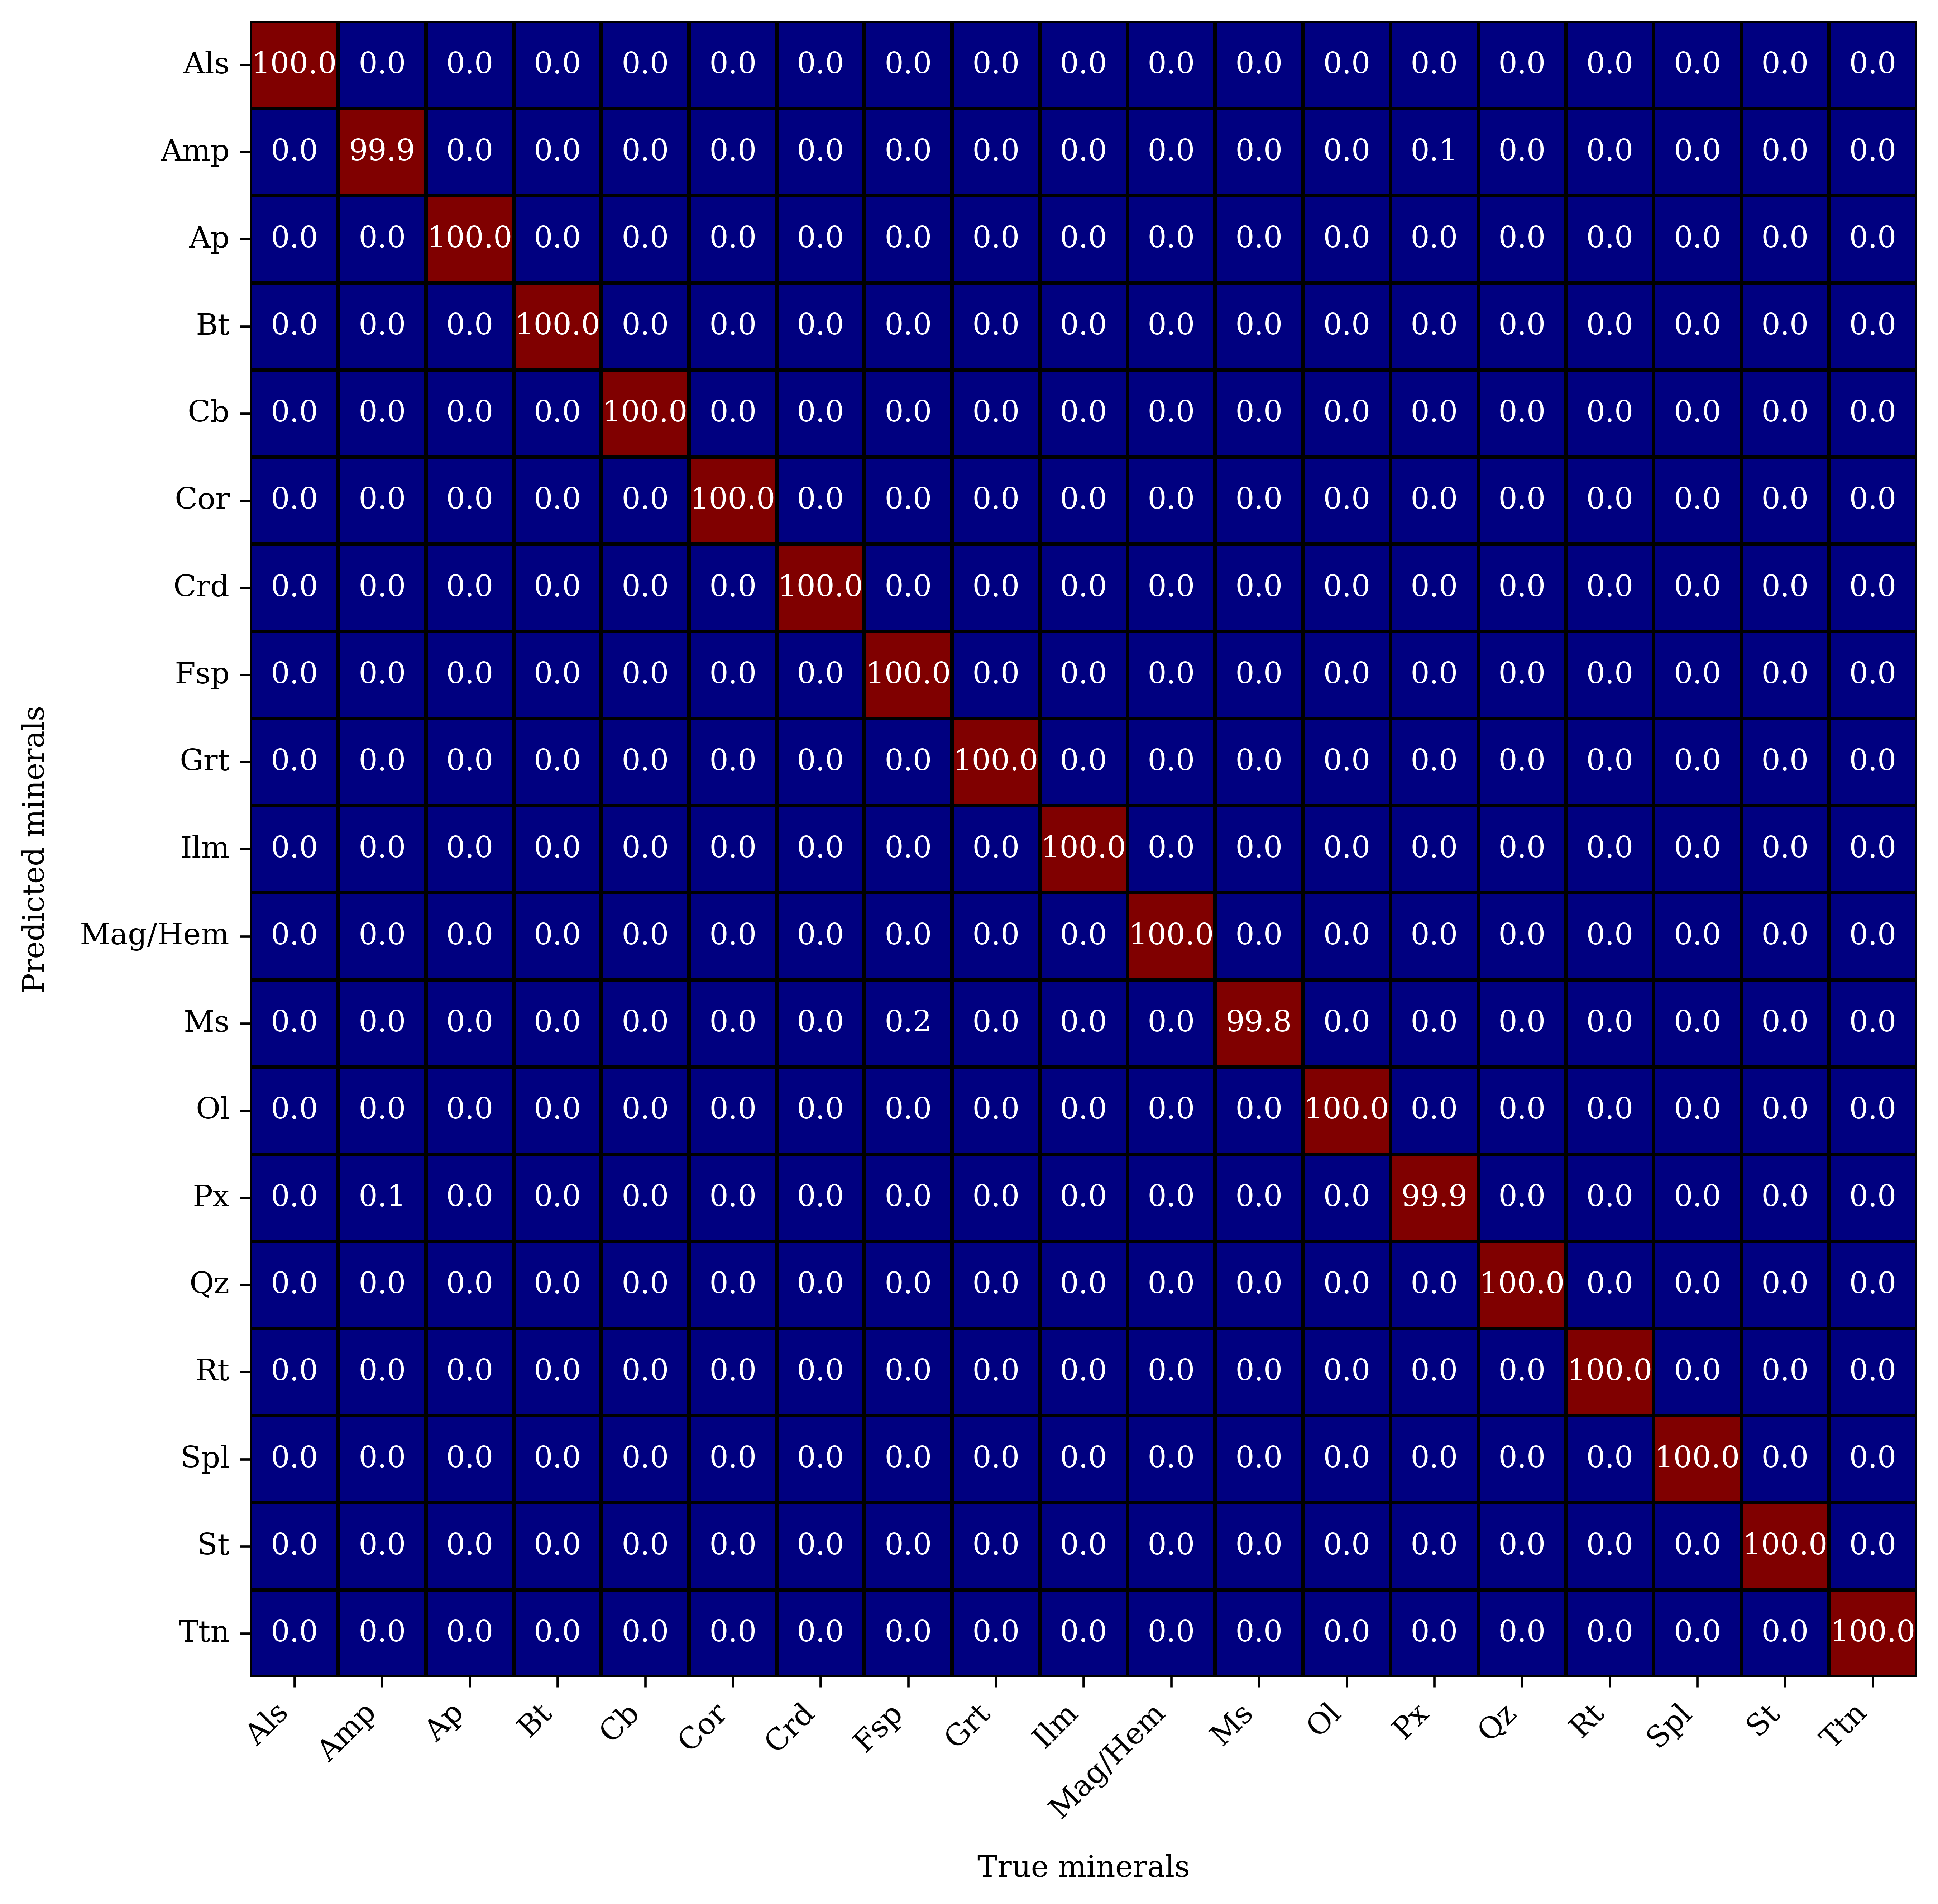

In [7]:
data = data1.copy()

data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data['M'] = data['FeO']+data['MgO']+data['MnO']#+data['CaO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")
# data.pop("CaO")

data['A'] = data["K2O"]+data["Na2O"]
data.pop("K2O")
data.pop("Na2O")
data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A','P2O5','CO2','Mineral']]

# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(data.iloc[:,:-2])

data_scaled = data.iloc[:,:-1].to_numpy()

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for FeO+MnO+MgO and Na2O+K2O input data\n")

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
# a = round(f1_score(test_label, pred_label, average=over_metrics),4)*100
# print(round(a,2))
# acc_table[0,2] = a

a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,2] = a
precision_table[0,2] = p
recall_table[0,2] = r
print(round(a,2))


cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("RF_C3.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1,average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,2] = a
    precision_table[i+1,2] = p
    recall_table[i+1,2] = r
    acc_table[i+1,2] = a
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

dump(model,"RF_C3.mdl")
# dump(scaler,"Scaler_C3.scl")
dump(labeler,"Labeler_C3.lbl")


Testing for FeO+MnO+MgO+CaO and CaO+Na2O+K2O input data

99.93
Als: accuracy: 100.0
Amp: accuracy: 99.96000000000001
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 99.96000000000001
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 99.85000000000001
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 99.92


['Labeler_C4.lbl']

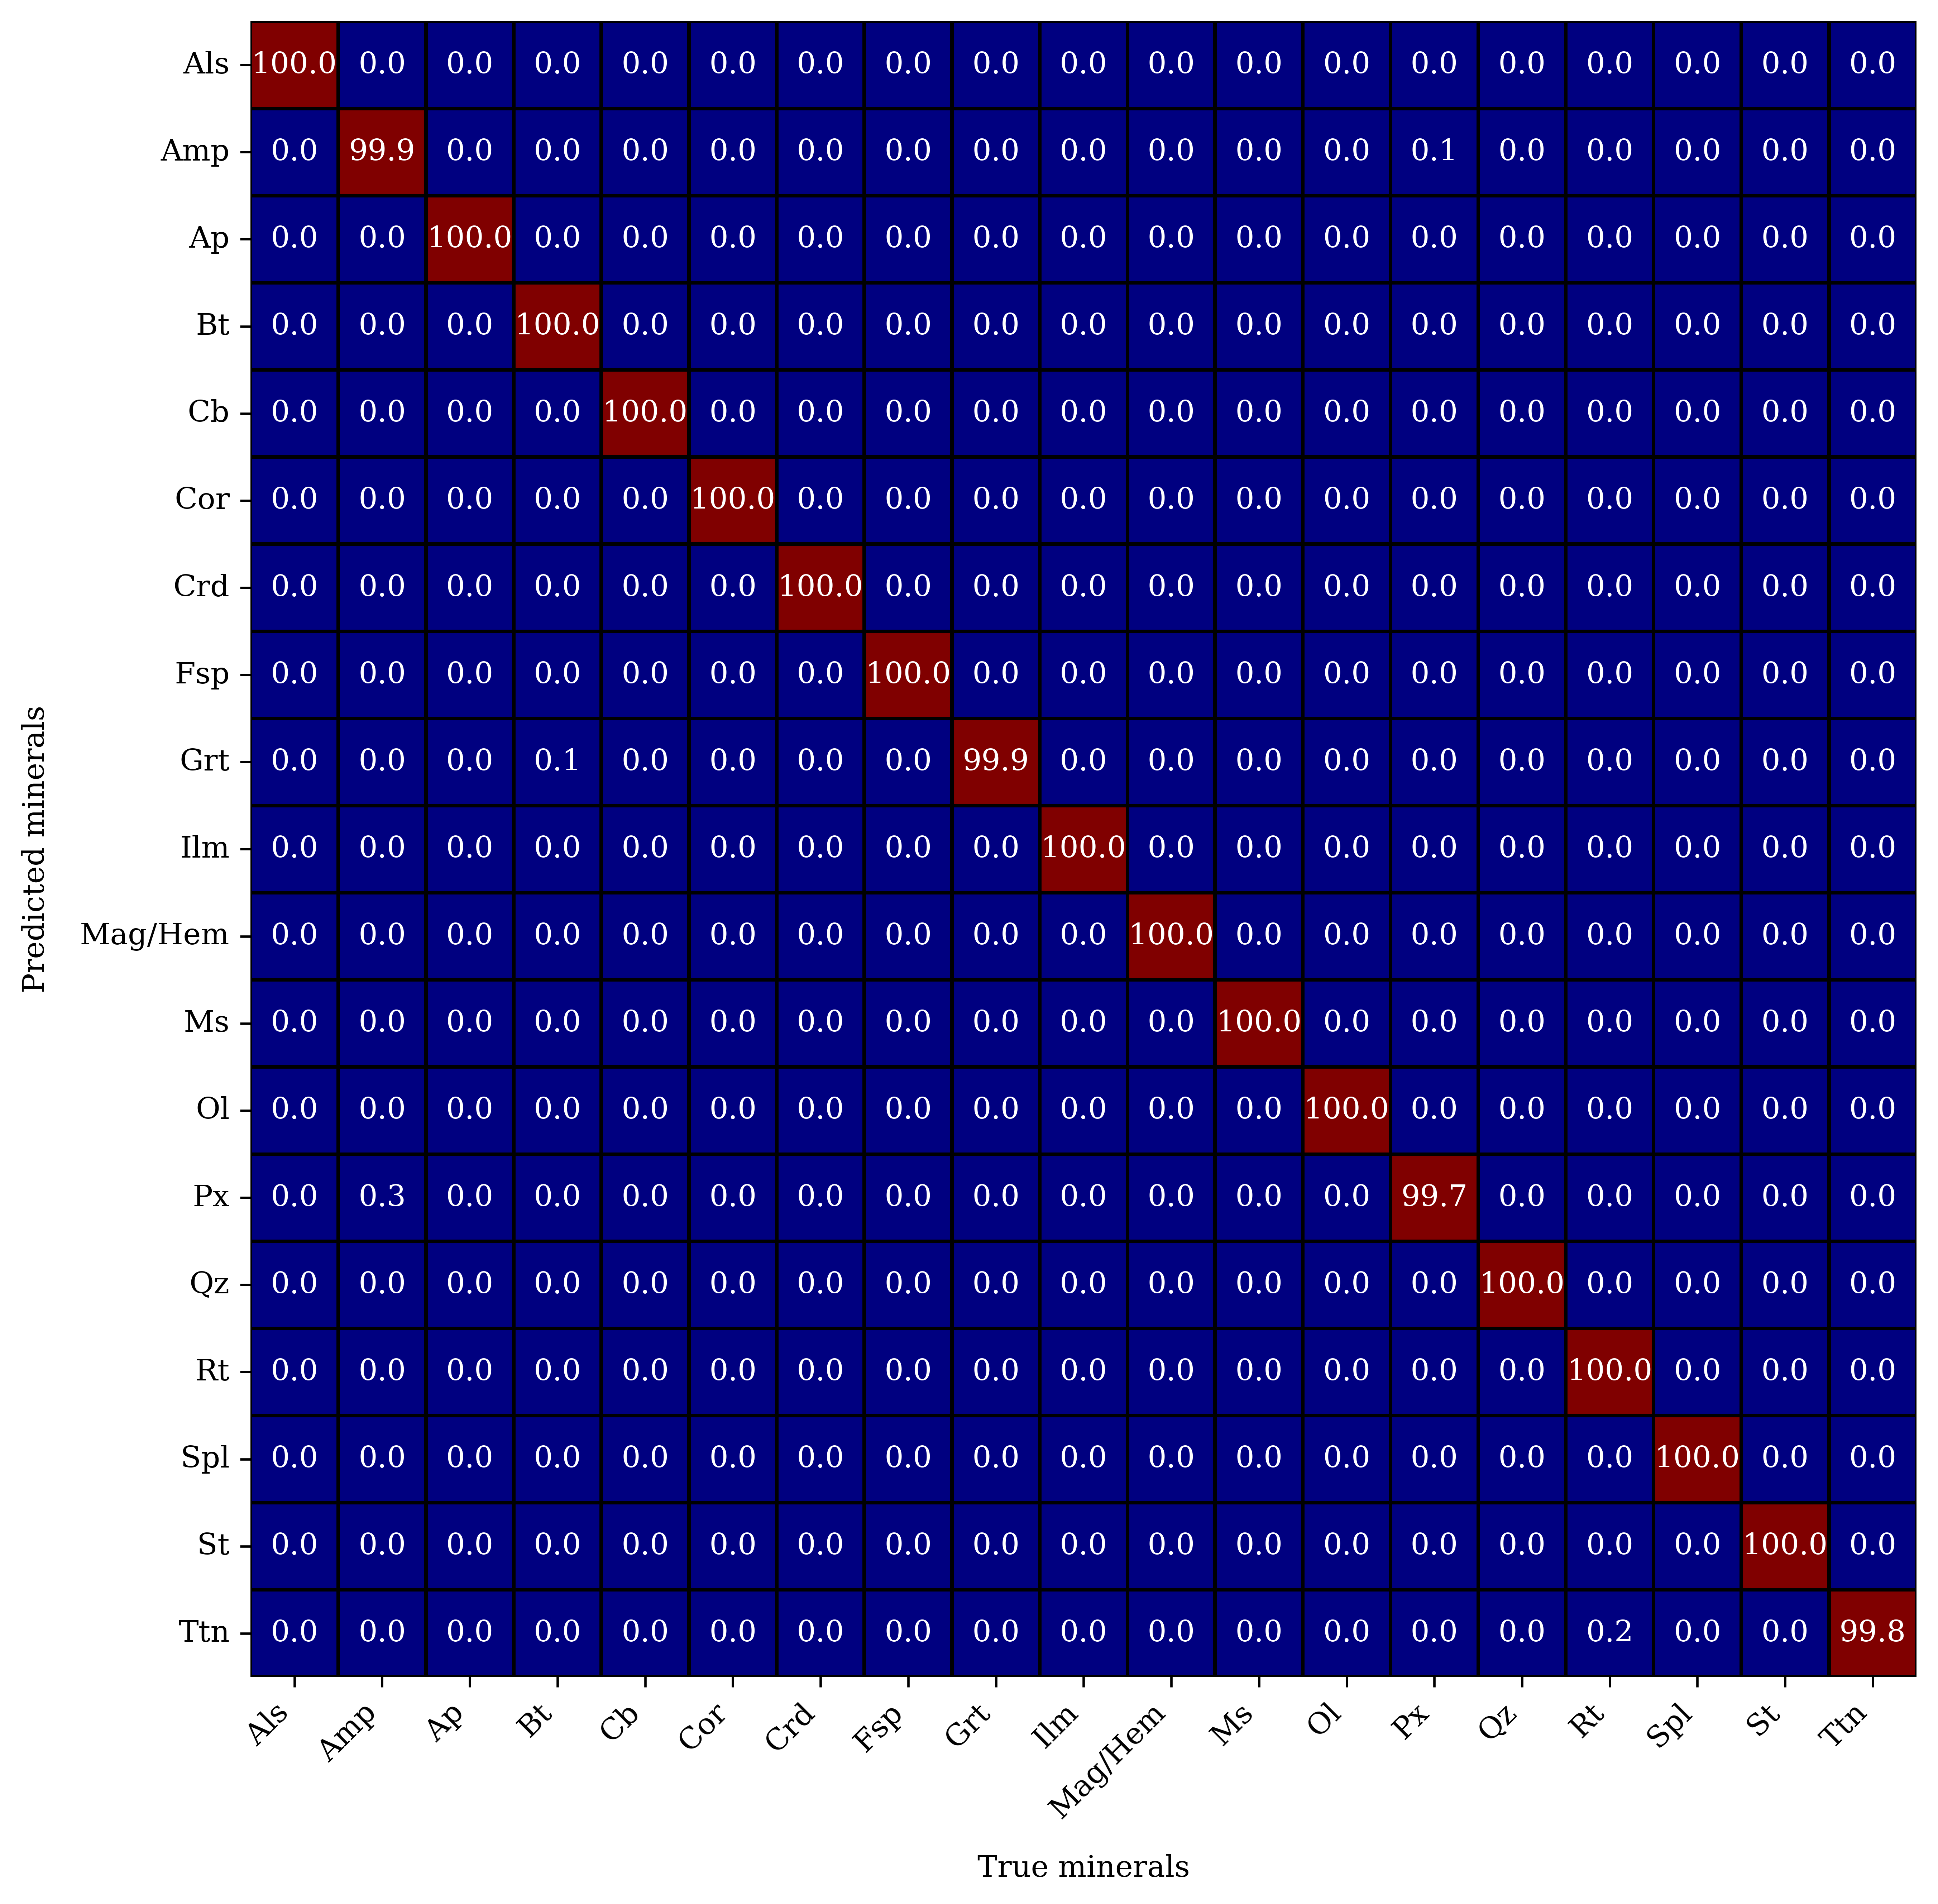

In [8]:
data = data1.copy()

data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data['M'] = data['FeO']+data['MgO']+data['MnO']+data['CaO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")


data['A'] = data["K2O"]+data["Na2O"]+data['CaO']
data.pop("K2O")
data.pop("Na2O")
data.pop("CaO")
data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'A', 'P2O5', 'CO2', 'Mineral']]

# data['A1'] = data["Na2O"]+data['CaO']
# data['A2'] = data["Na2O"]+data['K2O']
# data.pop("K2O")
# data.pop("Na2O")
# data.pop("CaO")
# data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'A1','A2', 'P2O5', 'CO2', 'Mineral']]


# data['Al/Si'] = (data["Al2O3"]-data['SiO2'])/(data['SiO2']+data['Al2O3'])

# data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A', 'Al/Si',
#        'Mineral', 'Source']]
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(data.iloc[:,:-2])

data_scaled = data.iloc[:,:-1].to_numpy()

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for FeO+MnO+MgO+CaO and CaO+Na2O+K2O input data\n")


model.fit(train_data, train_label)
pred_label = model.predict(test_data)
# a = round(f1_score(test_label, pred_label, average=over_metrics),4)*100
# acc_table[0,3] = a

a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
acc_table[0,3] = a
precision_table[0,3] = p
recall_table[0,3] = r
print(round(a,2))
cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("RF_C4.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
    acc_table[i+1,3] = a
    precision_table[i+1,3] = p
    recall_table[i+1,3] = r
    acc_table[i+1,3] = a
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

dump(model,"RF_C4.mdl")
# dump(scaler,"Scaler_C4.scl")
dump(labeler,"Labeler_C4.lbl")


Testing for PCA (n=5) transformed input data

99.77
Als: accuracy: 100.0
Amp: accuracy: 99.87
Ap: accuracy: 100.0
Bt: accuracy: 99.87
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 99.92
Grt: accuracy: 99.38
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 99.76
Ol: accuracy: 100.0
Px: accuracy: 99.76
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 99.92

Testing for PCA (n=6) transformed input data

99.87
Als: accuracy: 100.0
Amp: accuracy: 99.83999999999999
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 99.87
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 99.76
Ol: accuracy: 100.0
Px: accuracy: 99.85000000000001
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 99.92


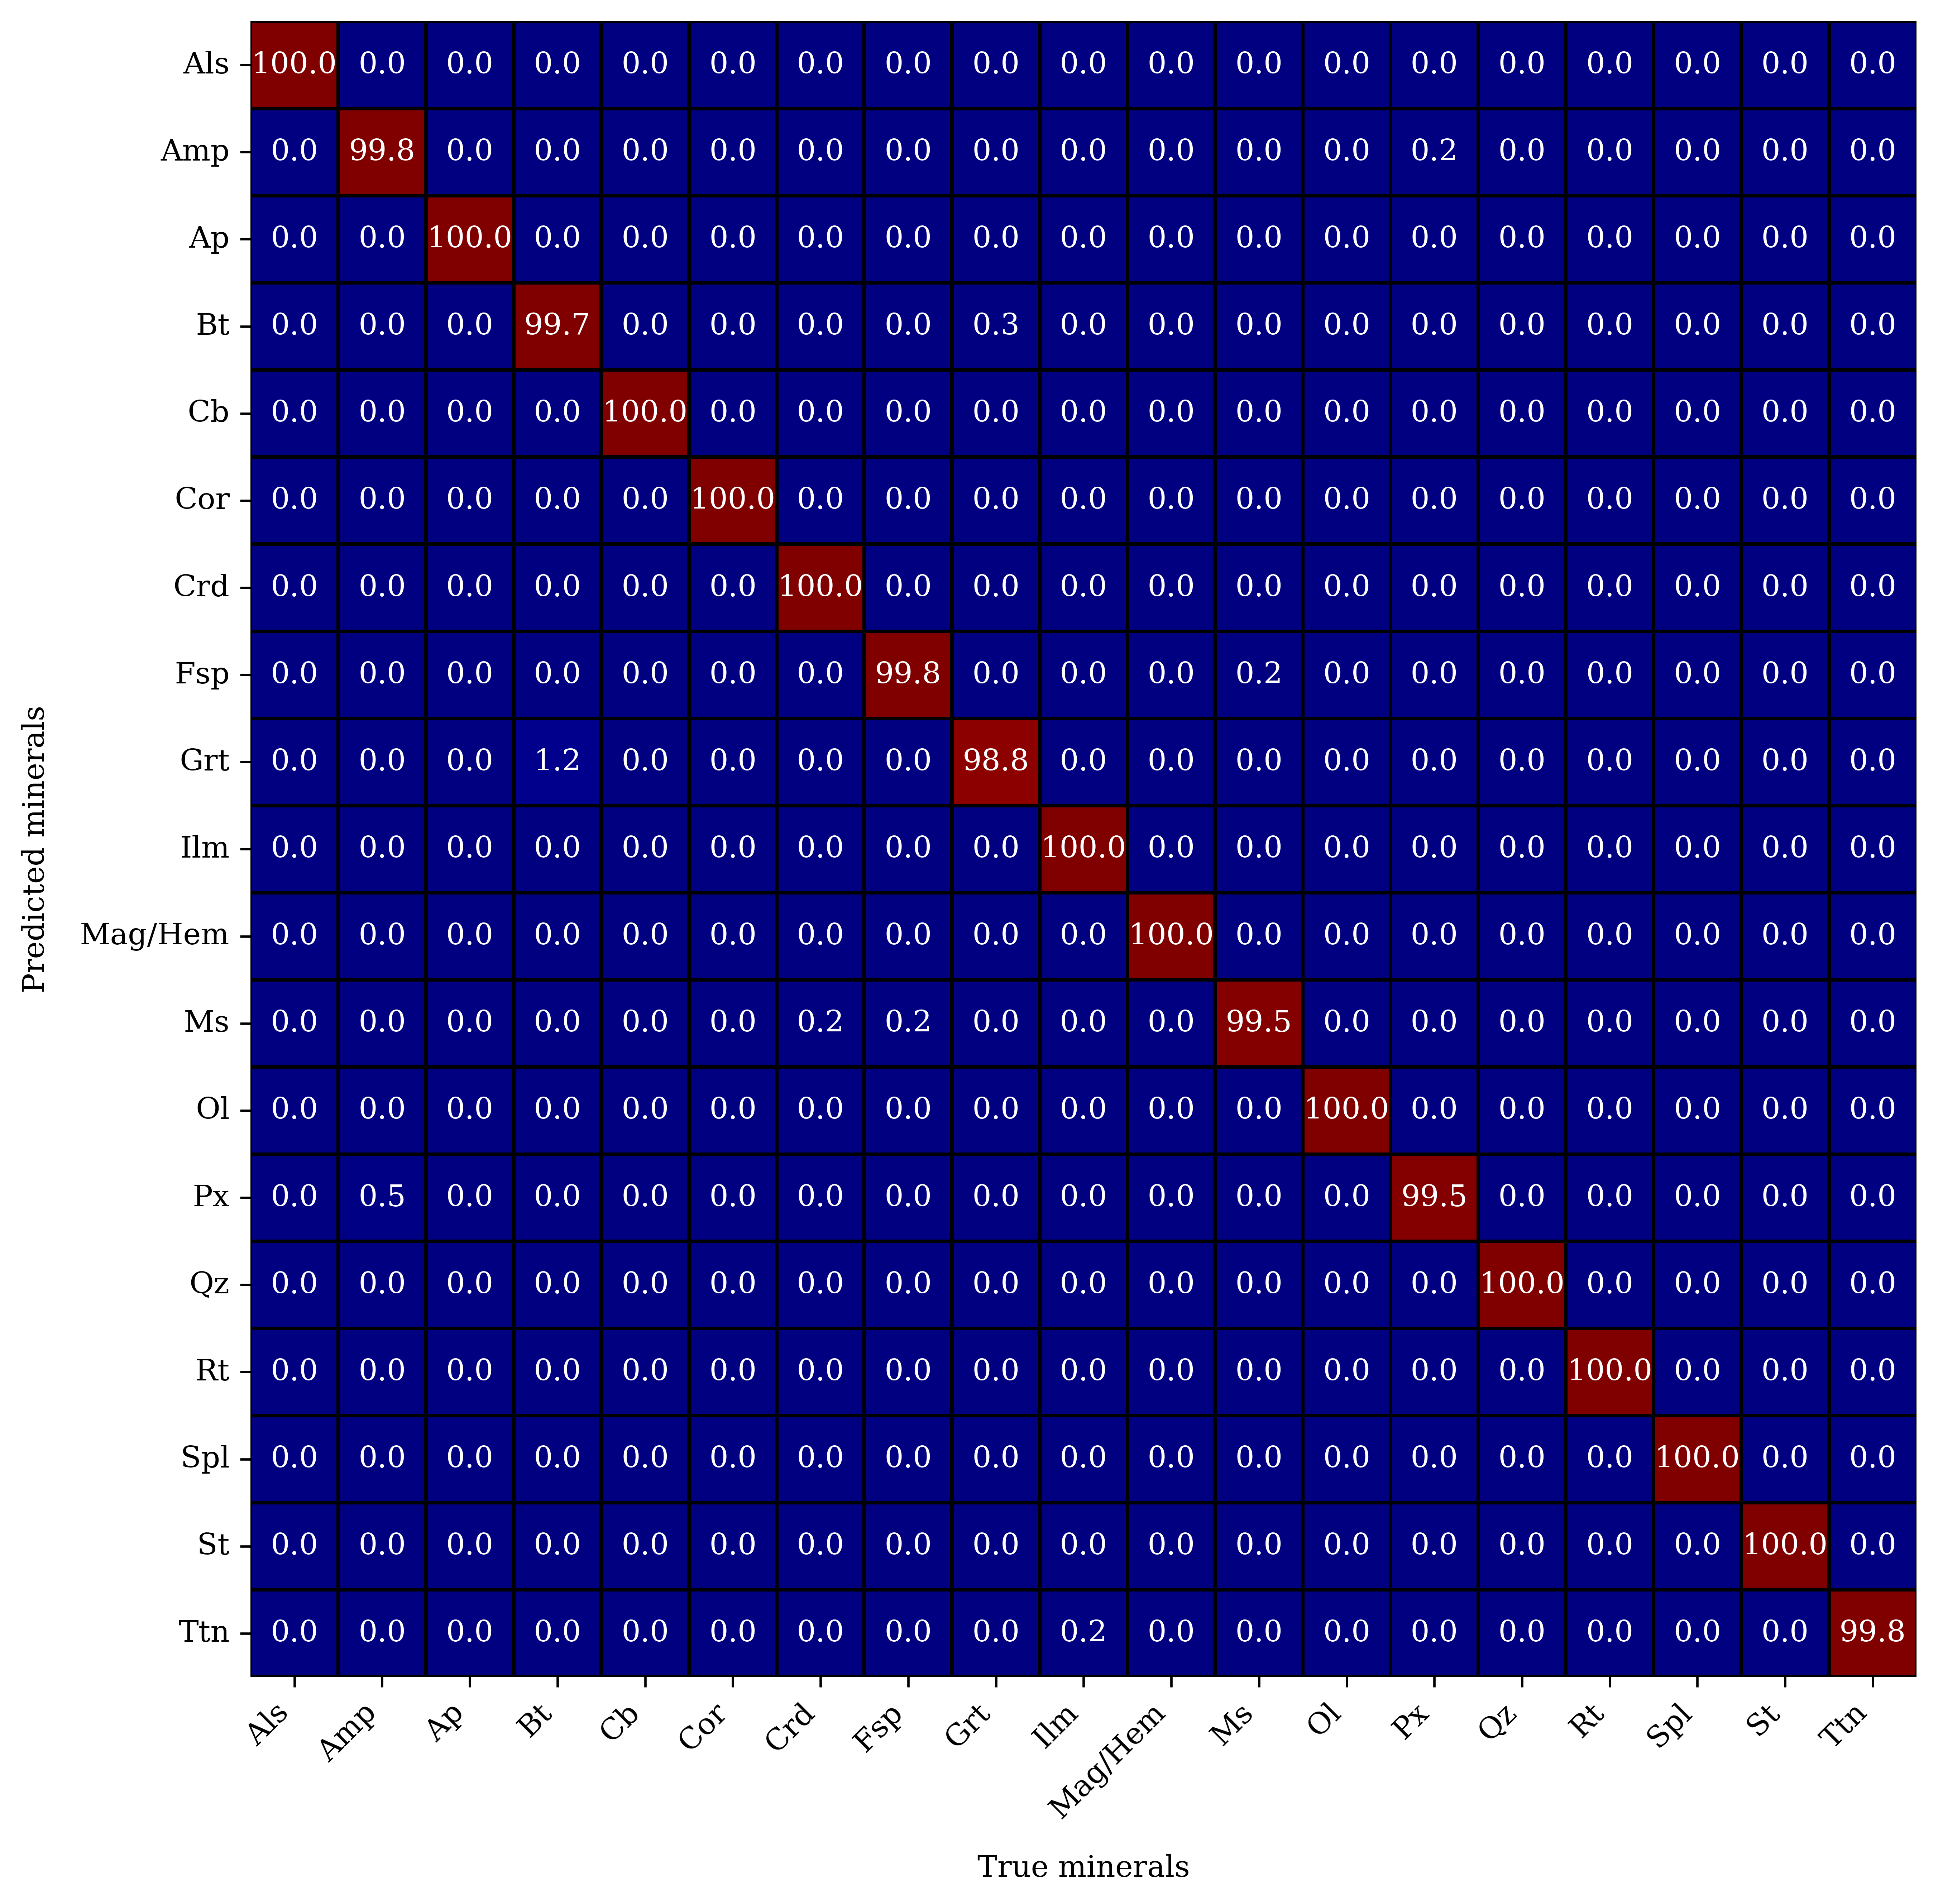

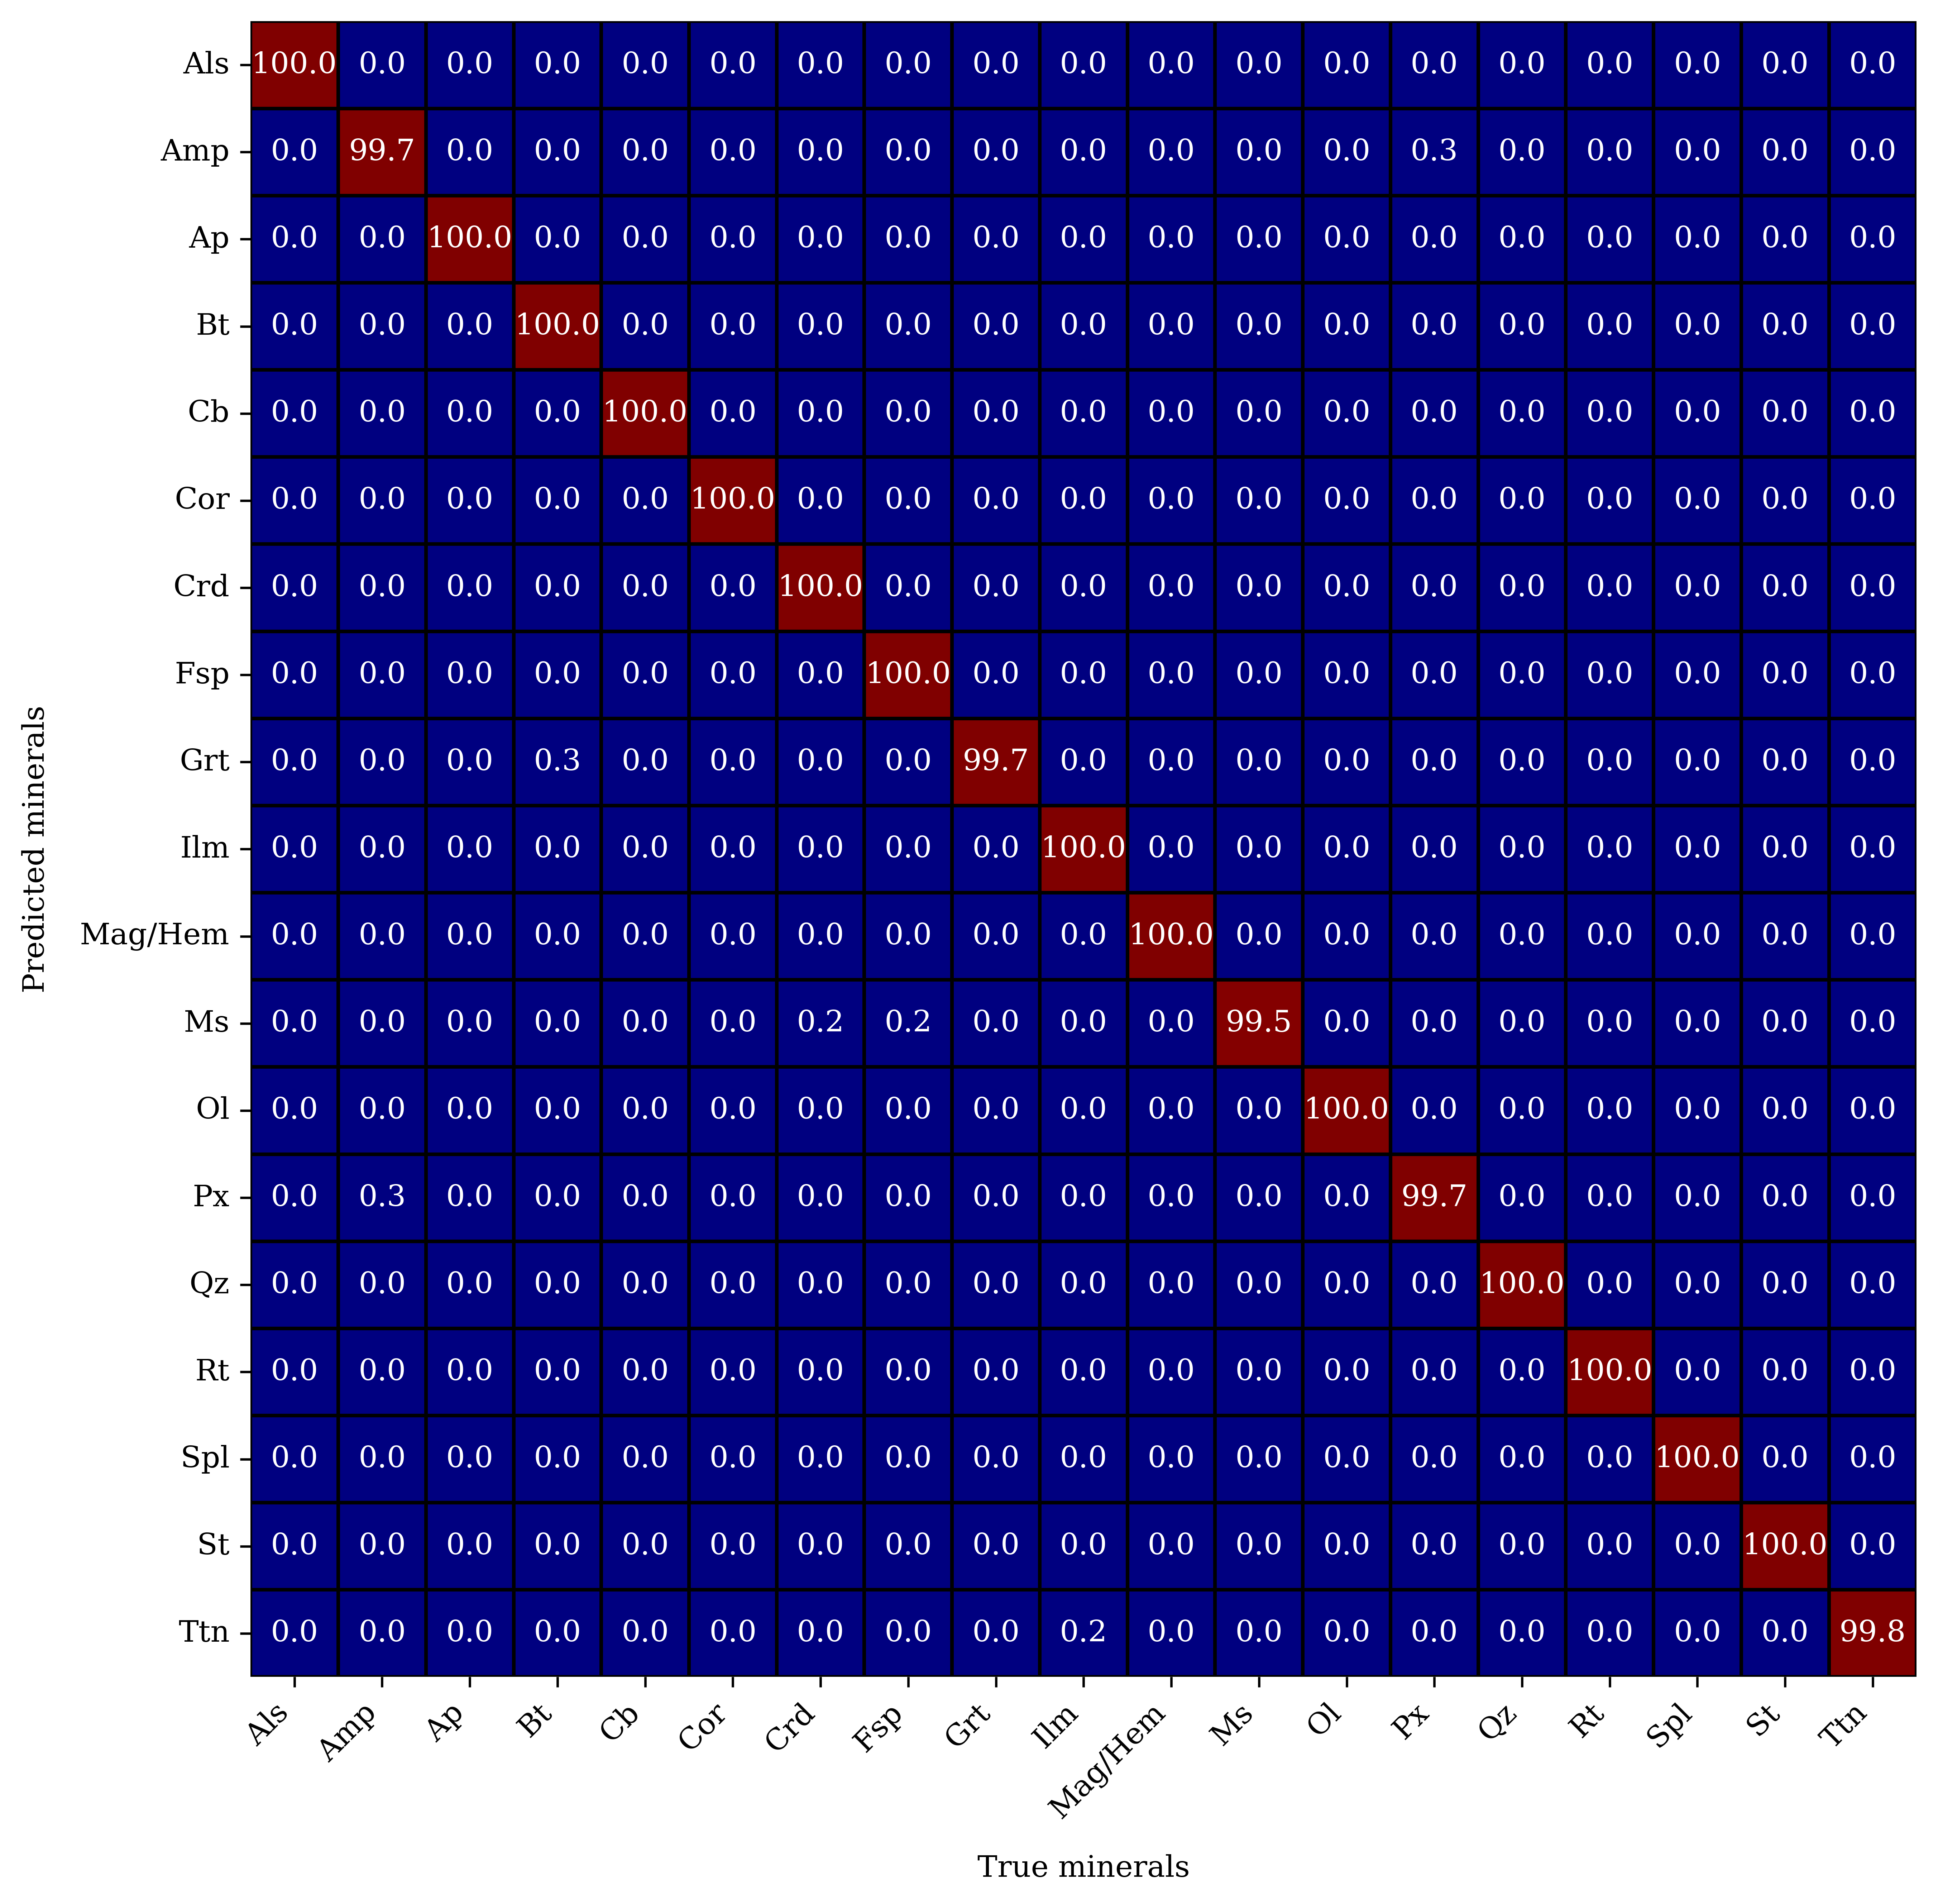

In [9]:
data = data1.copy()

data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(data.iloc[:,:-2])

data_scaled  = data.iloc[:,:-1].to_numpy()

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

for i in range(5,7):
    
    print(f"\nTesting for PCA (n={i}) transformed input data\n")
    data_scaled = data_scaled.copy()
    pca = PCA(n_components=i,svd_solver="full")
    pca_normalized_data = pca.fit_transform(data_scaled)
    train_data = pca_normalized_data[split1[0],:]
    train_label = target[split1[0]]
    test_data = pca_normalized_data[split1[1],:]
    test_label = target[split1[1]]
    model.fit(train_data, train_label)
    pred_label = model.predict(test_data)
    # a = round(f1_score(test_label, pred_label, average=over_metrics),4)*100
    
    a = round(f1_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
    r = round(recall_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
    p = round(precision_score(test_label, pred_label, average=over_metrics,zero_division=np.nan),4)*100
    acc_table[0,i+3] = a
    precision_table[0,i+3] = p
    recall_table[0,i+3] = r
    print(round(a,2))
    # acc_table[0,i+3] = a
    cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
    cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
    plt.figure(figsize=figsize,dpi=600)
    sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
    plt.xticks(rotation=45,ha='right')
    plt.xlabel("True minerals",labelpad=10)
    plt.ylabel("Predicted minerals",labelpad=10)
    plt.savefig("RF_C5.pdf",bbox_inches='tight')
     
    for j in range(0,minerals-1):
        test_data1 = test_data[test_label==j]
        test_label1 = test_label[test_label==j]
        pred_label1 = model.predict(test_data1)
        a = round(f1_score(test_label1, pred_label1, average=sample_metrics),4)*100
        acc_table[j+1,i+3] = a
        
        a = round(f1_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        r = round(recall_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        p = round(precision_score(test_label1, pred_label1, average=sample_metrics,zero_division=np.nan),4)*100
        acc_table[j+1,i+3] = a
        precision_table[j+1,i+3] = p
        recall_table[j+1,i+3] = r
        acc_table[j+1,i+3] = a
        name = labeler.inverse_transform([j])[0]
        print(f"{name}: accuracy: {a}")
    dump(model,"RF_C5_"+str(i)+"_components.mdl")
    # dump(scaler,"Scaler_C5_"+str(i)+"_components.scl")
    dump(labeler,"Labeler_C5_"+str(i)+"_components.lbl")
    dump(pca,"PCA_C5_"+str(i)+"_components.pc")
data_scaled1 = pca.transform(data_scaled)
pred_label = model.predict(data_scaled1)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]



In [10]:
l = ["Overall"]
l.extend([i for i in labeler.classes_])
# acc_table = pd.DataFrame(acc_table,
#                           columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO+CaO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed"],
#                           index=["Overall", "Als", "Amp", "Ap", "Bt","Crd", 
#                                  "Fsp", "Grt", "Ilm","Mag", 'Ms','Ol','Pg',
#                                  'Px',"Qz",'Rt', 'Spl', 'St', 'Ttn'])
acc_table = pd.DataFrame(acc_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed", "PCA (n=9) transformed", "PCA (n=10) transformed"],
                          index=l)
recall_table = pd.DataFrame(recall_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed", "PCA (n=9) transformed", "PCA (n=10) transformed"],
                          index=l)

precision_table = pd.DataFrame(precision_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed", "PCA (n=9) transformed", "PCA (n=10) transformed"],
                          index=l)

In [11]:
path = "D:/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/RF/"

acc_table.to_excel(path+r"F1-score Accuracy report for RF1.xlsx")
# # acc_table.to_excel(r"/home/avi/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/SVM/F1-score Accuracy report for SVM_withoutamph.xlsx")
recall_table.to_excel(path+r"Recall-score Accuracy report for RF1.xlsx")
precision_table.to_excel(path+r"Precision-score Accuracy report for RF1.xlsx")

In [12]:
np.round(model.feature_importances_,2,)


array([0.16, 0.23, 0.21, 0.11, 0.08, 0.2 ])

In [13]:
# model.estimator_params
# model.estimators_samples_

In [14]:
model.max_leaf_nodes

In [15]:
model.decision_path(test_data)

(<18813x15964 sparse matrix of type '<class 'numpy.int64'>'
 	with 11582729 stored elements in Compressed Sparse Row format>,
 array([    0,   331,   680,  1041,  1360,  1665,  2008,  2363,  2604,
         2939,  3232,  3557,  3948,  4271,  4618,  4929,  5224,  5481,
         5754,  6033,  6362,  6651,  6978,  7251,  7580,  7951,  8292,
         8655,  8966,  9311,  9590,  9929, 10208, 10517, 10842, 11169,
        11432, 11753, 12112, 12427, 12760, 13093, 13450, 13763, 14078,
        14369, 14654, 14927, 15310, 15677, 15964]))

In [16]:
model.estimators_[0]

DecisionTreeClassifier(max_features='sqrt', random_state=1365099638)